# Introducción al Machine Learning - Semana 5
## Caso: Aplicación de árboles de decisión y ensamblajes

### Propósito de la actividad

En esta actividad podrán poner en práctica, con un conjunto de datos reales, su habilidad para implementar modelos basados en árboles y ensamblajes para seleccionar aquel que tenga el mejor desempeño para resolver un problema de clasificación. En particular, se deberán implementar modelos de árboles sencillos, random forest y gradient boosting.

Además, como en todo procedimiento de analítica de datos, se evaluará la exploración preliminar de los datos por medio de herramientas como histogramas, correlogramas y estadísticas descriptivas.

### Instrucciones generales

1. Para desarrollar el notebook, lo deberán descargar a un repositorio (pueden escoger el repositorio de su preferencia) para que lo puedan trabajar grupalmente.

2. Los procedimientos en el notebook deberán responderse en los espacios especificados para tal fin, debajo de cada uno de los puntos.

3. Para que la actividad sea calificada, deberán subir únicamente este mismo archivo con la extensión ".ipynb" a la actividad de "entrega calificada por el personal" correspondiente a este caso.

4. El archivo que suban debe poder ejecutarse localmente cuando sea descargado por el tutor, asumiendo que la base de datos de la actividad ya ha sido importada en el correspondiente archivo separado por comas (.csv).

### Criterios de evaluación

Los criterios que se evaluarán son: 

Análisis preliminar de variables: Se presentan correlogramas, histogramas y estadísticas descriptivas de las variables de la base de datos y se hace un análisis coherente de cada uno de ellos. [10 puntos] 

Estimación modelo de árbol de decisión: Se estima el modelo usando un árbol de decisión, se evalúa su desempeño en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [20 puntos] 

Estimación modelo de bagging: Se estima el modelo usando bagging, se evalúa su desempeño en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [20 puntos]

Estimación modelo de random forest: Se estima el modelo usando random forest, se evalúa su desempeño en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [20 puntos] 

Estimación modelo de gradient boosting: Se estima el modelo usando gradient boosting, se evalúa su desempeño en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [20 puntos] 

Elección del mejor modelo: Se elige el mejor modelo de acuerdo a los resultados obtenidos y se justifica adecuadamente la elección. [10 puntos] 


### Datos

En esta ocasión usarán una base de datos disponible en la página R-Data. Esta base de datos corresponde a "Weekly", la cual contiene 8 variables predictivas sobre el índice bursátil S&P500 y 1089 observaciones. De esta manera, el objetivo de la actividad es predecir si el precio del índice subirá o bajará la semana siguiente.

Por lo anterior, en primer lugar deberán descargar la base de datos del siguiente enlace: https://r-data.pmagunia.com/dataset/r-dataset-package-islr-weekly

In [2]:
#  Cargar librerías
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd  
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("Weekly.csv")
df

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,0
1,1990,-2.708,-2.428,-2.259,-1.552,2.480,0.192706,-2.292,0
2,1990,-2.292,-2.708,-2.428,-2.259,-1.552,0.148252,-4.978,0
3,1990,-4.978,-2.292,-2.708,-2.428,-2.259,0.189858,3.547,1
4,1990,3.547,-4.978,-2.292,-2.708,-2.428,0.127884,0.260,1
...,...,...,...,...,...,...,...,...,...
1084,2010,-4.226,2.232,-6.388,-2.513,2.110,6.528052,0.158,1
1085,2010,0.158,-4.226,2.232,-6.388,-2.513,5.528868,-2.252,0
1086,2010,-2.252,0.158,-4.226,2.232,-6.388,5.368597,2.509,1
1087,2010,2.374,2.509,-2.252,0.158,-4.226,4.637208,-3.646,0


In [4]:
# Se eliminar filas con valores faltantes en caso de haber y la variable que indific acantidad de registros (Unnamed: 0)
df = df.dropna(subset=['Direction']).reset_index(drop=True)
df = df.sort_values(by='Year')
df.replace({'Direction': {'Up': 1, 'Down': 0}}, inplace=True)

yTotal = df['Direction'].astype(str).str.strip().str.title().to_numpy()  # 'Up'/'Down'
XTotal = df.drop(columns=['Direction', 'Unnamed: 0','Today'], errors='ignore').to_numpy()

In [5]:
split = int(len(df)*0.67)

XTrain = XTotal[:split]
XTest = XTotal[split:]

yTrain = yTotal[:split]
yTest = yTotal[split:]

###  Análisis preliminar de variables (10 puntos)
Realicen un análisis preliminar de los predictores y de la variable de respuesta (correlogramas, histogramas y estadísticas descriptivas).

=== Estadísticas descriptivas ===


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899,0.555556
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927,0.497132
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000,0.000000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000,0.000000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000,1.000000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000,1.000000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000,1.000000



=== Distribución de la variable Direction ===
Direction
1    605
0    484
Name: count, dtype: int64
Direction
1    0.555556
0    0.444444
Name: proportion, dtype: float64


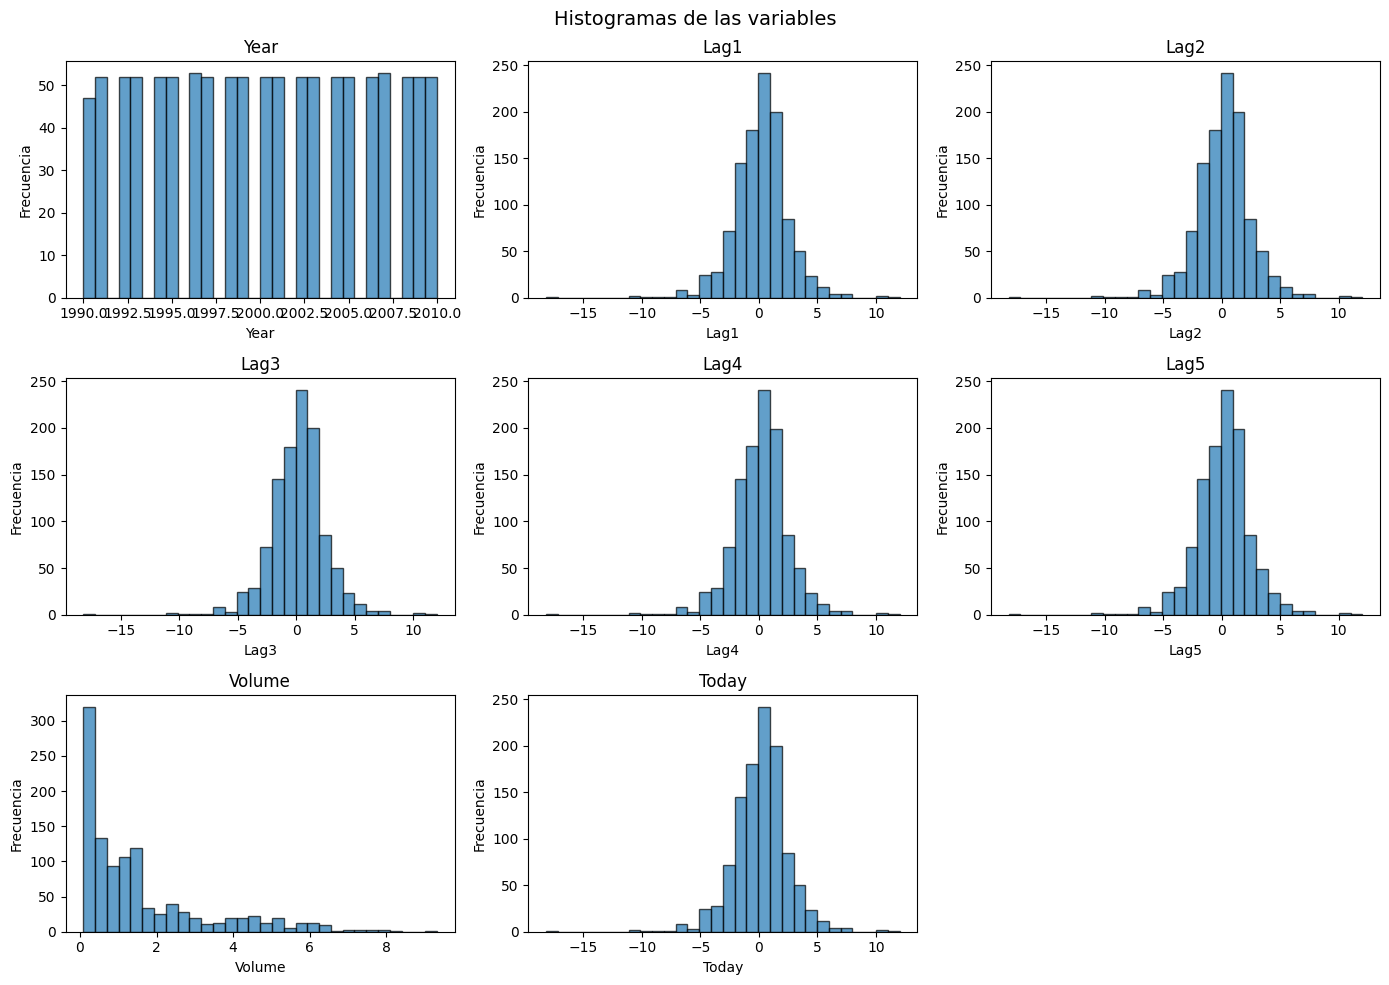

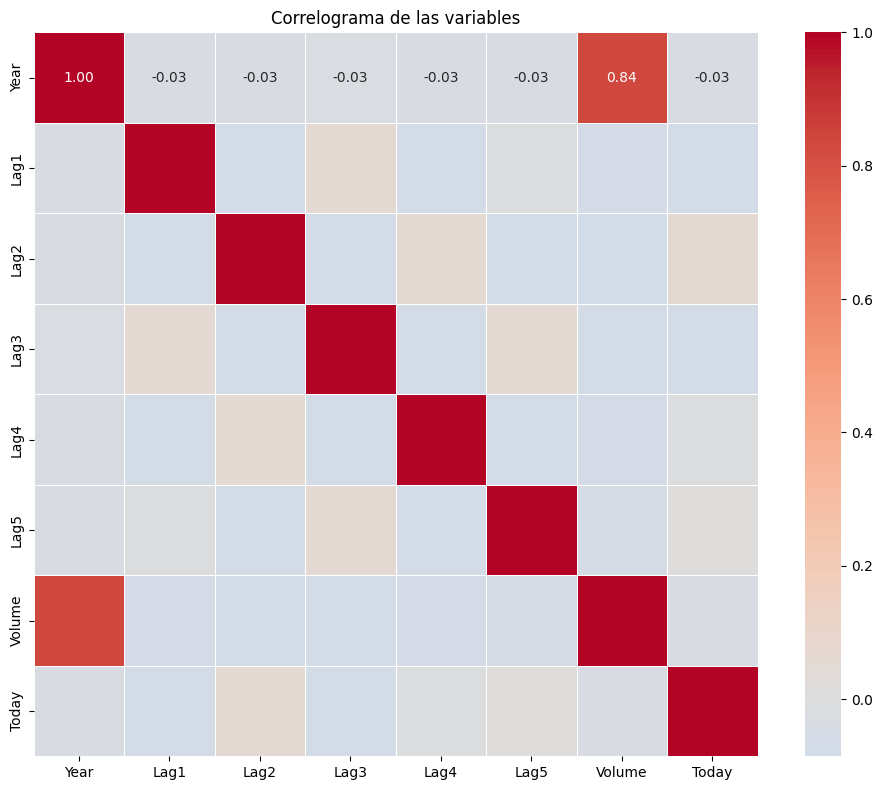

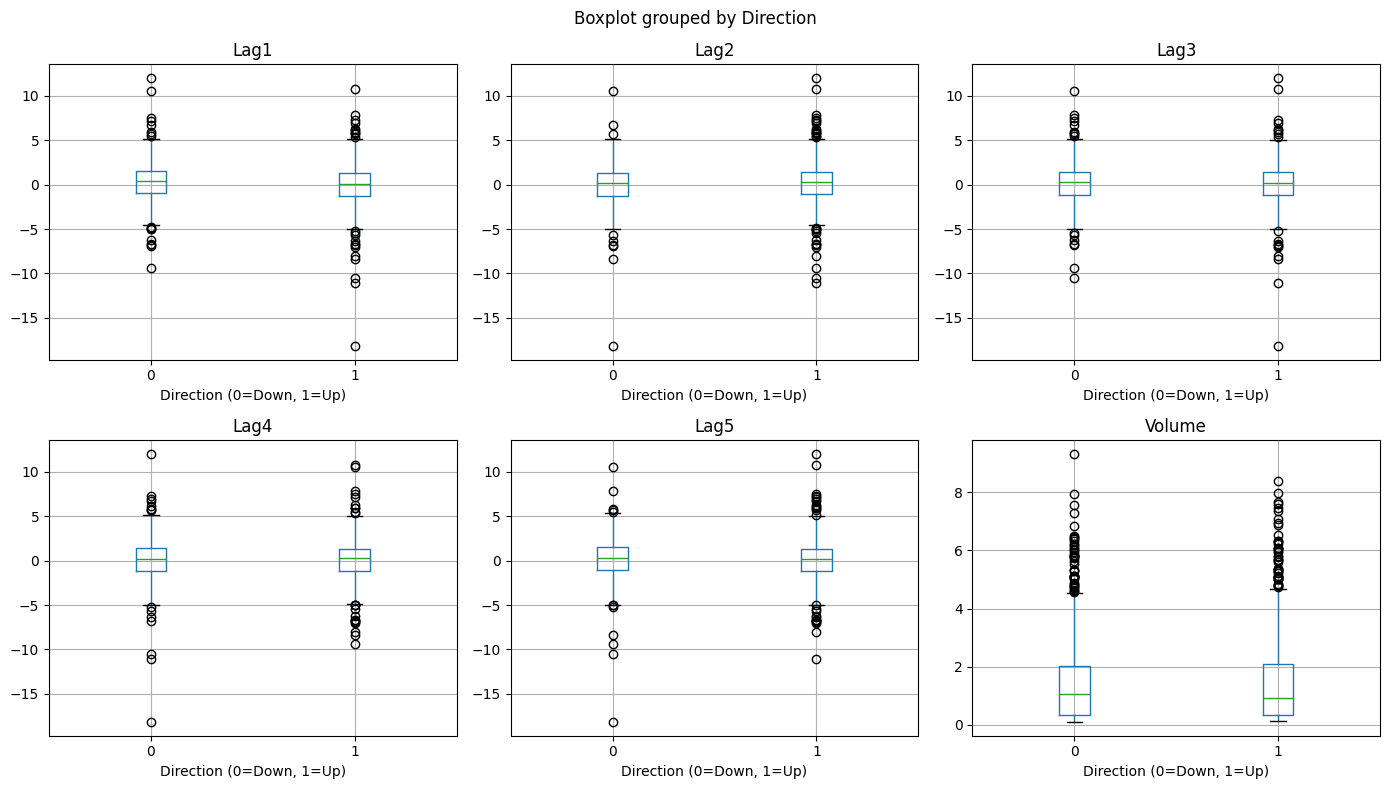

In [7]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 1 ####

print("=== Estadísticas descriptivas ===")
display(df.describe())

# Distribución de la variable de respuesta
print("\n=== Distribución de la variable Direction ===")
print(df['Direction'].value_counts())
print(df['Direction'].value_counts(normalize=True))

# Histogramas de todas las variables numéricas
variables_numericas = df.drop(columns=['Direction', 'Unnamed: 0'], errors='ignore')

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Histogramas de las variables", fontsize=14)
axes = axes.flatten()

for i, col in enumerate(variables_numericas.columns):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

# Ocultar ejes sobrantes si hay menos variables que subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Correlograma
plt.figure(figsize=(10, 8))
corr = variables_numericas.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlograma de las variables")
plt.tight_layout()
plt.show()

# Boxplots por clase de Direction
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Boxplots por clase de Direction", fontsize=14)
axes = axes.flatten()
predictores = ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']

for i, col in enumerate(predictores):
    df.boxplot(column=col, by='Direction', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Direction (0=Down, 1=Up)")

plt.tight_layout()
plt.show()



(Utilicen este espacio para describir su procedimiento y escribir su análisis y conclusiones sobre el punto 1)
#### Análisis y Conclusión punto 1

**Estadísticas descriptivas:** El dataset contiene 1089 observaciones semanales del índice S&P500 entre 1990 y 2010. Las variables Lag1 a Lag5 representan los retornos porcentuales de las 5 semanas anteriores, con medias cercanas a cero y desviaciones estándar alrededor de 2.3-2.4%, lo cual es consistente con el comportamiento típico de retornos financieros. La variable Volume muestra el volumen promedio de transacciones, con una media de 1.57 y un rango que va desde 0.087 hasta 9.328, indicando un incremento considerable del volumen a lo largo del tiempo. La variable Today tiene una media de 0.15%, ligeramente positiva, reflejando la tendencia alcista del mercado a largo plazo.

**Distribución de la variable de respuesta:** La variable Direction presenta un ligero desbalance, con aproximadamente un 55.5% de semanas al alza (Up=1) frente a un 44.5% de semanas a la baja (Down=0). Este desbalance no es severo, por lo que no debería afectar significativamente el entrenamiento de los modelos.

Los retornos semanales (Lag1-Lag5 y Today) presentan distribuciones aproximadamente simétricas y centradas en cero, con colas más pesadas que una distribución normal, lo cual es típico de datos financieros (leptocurtosis). La variable Volume presenta una distribución sesgada a la derecha. La variable Year se distribuye de forma uniforme, ya que cubre el periodo 1990-2010 con observaciones semanales.

### 2. Estimación modelo de árbol de decisión (20 puntos)
Estimen un árbol de decisión con la muestra de entrenamiento y calculen su poder predictivo evaluándolo en la muestra de test.

max_depth=1, AUC promedio es 0.5215
max_depth=2, AUC promedio es 0.5225
max_depth=3, AUC promedio es 0.5355
max_depth=4, AUC promedio es 0.5339
max_depth=5, AUC promedio es 0.5026
max_depth=6, AUC promedio es 0.5069
max_depth=7, AUC promedio es 0.5171
max_depth=8, AUC promedio es 0.5188
max_depth=9, AUC promedio es 0.5112
max_depth=10, AUC promedio es 0.5049
max_depth=11, AUC promedio es 0.5150
max_depth=12, AUC promedio es 0.5181
max_depth=13, AUC promedio es 0.5144
max_depth=14, AUC promedio es 0.5119
max_depth=15, AUC promedio es 0.5177
max_depth=16, AUC promedio es 0.5133
max_depth=17, AUC promedio es 0.5156
max_depth=18, AUC promedio es 0.5104
max_depth=19, AUC promedio es 0.5163
max_depth=20, AUC promedio es 0.5198


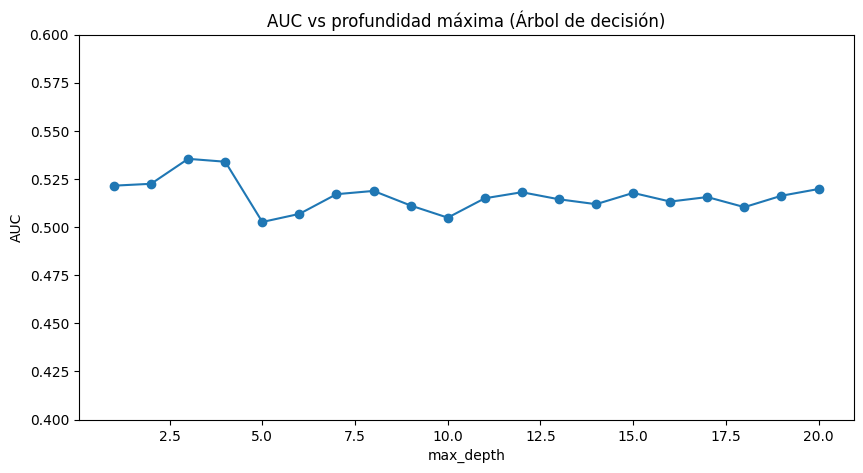

el mejor AUC es 0.5355 con max_depth=3


In [10]:
kf = TimeSeriesSplit(n_splits=10)

max_depth = range(1, 21)
auc_por_depth = []

for i in max_depth:
    auc_folds = []
    for train_idx, test_idx in kf.split(XTotal):
        X_trainCV, X_testCV = XTotal[train_idx], XTotal[test_idx]
        y_trainCV, y_testCV = yTotal[train_idx], yTotal[test_idx]

        clf = DecisionTreeClassifier(max_depth=i, random_state=0).fit(X_trainCV, y_trainCV)

        scores = clf.predict_proba(X_testCV)[:, 1]
        auc_folds.append(metrics.roc_auc_score(y_testCV, scores))

    auc_por_depth.append(np.mean(auc_folds))
    print(f"max_depth={i}, AUC promedio es {auc_por_depth[-1]:.4f}")
plt.figure(figsize=(10, 5))
plt.title("AUC vs profundidad máxima (Árbol de decisión)")
plt.plot(list(max_depth), auc_por_depth, marker='o')
plt.xlabel("max_depth")
plt.ylabel("AUC")
plt.ylim(0.4, 0.6)
plt.show()
mejorauc_Tree = max(auc_por_depth)
print(f"el mejor AUC es {mejorauc_Tree:.4f} con max_depth={max_depth[auc_por_depth.index(mejorauc_Tree)]}")

(Utilicen este espacio para describir su procedimiento y escribir su análisis y conclusiones sobre el punto 2)
#### Análisis y Conclusión punto 2

**Proceso:** Se implementó un modelo de árboles de decisión utilizando los datos de Weekly. Cabe recalcar que es necesario retirar la variable Today, debido a que la variable Direction depende completamente de este valor, por lo tanto, si se llega a usar como variable predictora, el modelo presentará métricas casi perfectas debido a una fuga de información.

En este caso, el modelo recibe como parámetros la profundidad máxima de los árboles y la semilla aleatoria. Se utilizó una semilla igual a 0 con el fin de poder reproducir los resultados. Por otra parte, en cuanto a la profundidad de los árboles, se realizó un proceso iterativo combinado con validación cruzada para lograr una mejor calibración del modelo. En este sentido, se utilizó una variación de la profundidad entre 1 y 20, donde para cada profundidad se aplicó validación cruzada con 10 folds. Estos folds se generaron mediante la función TimeSeriesSplit, con el objetivo de conservar la estructura temporal de los datos y mantener coherencia con el proceso de entrenamiento. Finalmente, para cada fold se calculó el AUC y se obtuvo el promedio entre folds, el cual fue utilizado para comparar las diferentes profundidades y determinar el desempeño del modelo.

**Conculsión:** En cuanto a los resultados, se obtuvo que el modelo seleccionado mediante el proceso iterativo corresponde a una profundidad de 3, con un AUC de 0.5355. Un AUC cercano a 0.5 sugiere que la capacidad del modelo para discriminar entre clases es baja, mostrando un comportamiento cercano al azar. Esto tiene sentido debido a que se trata de un dataset orientado a la predicción de movimientos del mercado, lo cual en la práctica es altamente complejo, ya que los precios financieros suelen comportarse como un random walk, donde el movimiento futuro presenta una alta incertidumbre y es difícil de predecir utilizando únicamente información histórica. Por lo tanto, este AUC refleja dicha limitación, indicando que con los datos disponibles el modelo tiene una capacidad muy limitada para anticipar si el precio aumentará o disminuirá.

Frente al comportamiento de aumentar la profundidad en cuanto a la capacidad predictiva del modelo, se puede observar que no existe un patrón claro, debido a que el AUC tiende a oscilar dentro de un rango similar, lo cual está relacionado con la limitada información predictiva disponible en el dataset. Por lo tanto, la estrategia de iterar sobre diferentes niveles de profundidad en este caso no genera mejoras significativas en el desempeño del modelo. Sin embargo, sí permite identificar la mejor configuración dentro de las opciones evaluadas. Adicionalmente, es importante tener precaución al incrementar excesivamente la profundidad, ya que esto puede llevar al sobreajuste (overfitting), haciendo que el modelo aprenda patrones específicos del conjunto de entrenamiento en lugar de generalizar correctamente.

### 3. Estimación modelo de bagging (20 puntos)
Estimen un modelo de bagging para árboles de decisión y calculen su poder predictivo evaluándolo en la muestra de test.

n_estimators=1, AUC promedio es 0.5038
n_estimators=2, AUC promedio es 0.5228
n_estimators=3, AUC promedio es 0.5411
n_estimators=4, AUC promedio es 0.5243
n_estimators=5, AUC promedio es 0.5255
n_estimators=6, AUC promedio es 0.5306
n_estimators=7, AUC promedio es 0.5323
n_estimators=8, AUC promedio es 0.5285
n_estimators=9, AUC promedio es 0.5352
n_estimators=10, AUC promedio es 0.5349
n_estimators=11, AUC promedio es 0.5363
n_estimators=12, AUC promedio es 0.5369
n_estimators=13, AUC promedio es 0.5400
n_estimators=14, AUC promedio es 0.5411
n_estimators=15, AUC promedio es 0.5433
n_estimators=16, AUC promedio es 0.5431
n_estimators=17, AUC promedio es 0.5461
n_estimators=18, AUC promedio es 0.5481
n_estimators=19, AUC promedio es 0.5483
n_estimators=20, AUC promedio es 0.5495


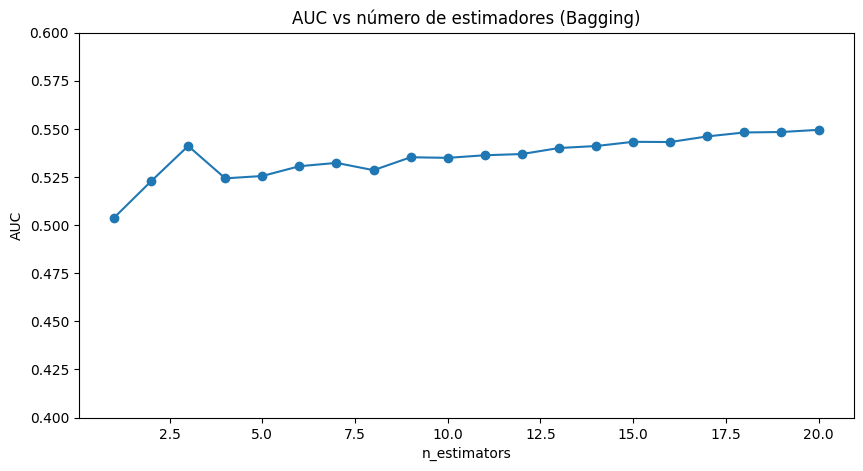

el mejor AUC es 0.5495 con n_estimators=20


In [13]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 3 ####


kf = TimeSeriesSplit(n_splits=10)

n_estimators = range(1, 21)
auc_por_nestimators = []

for i in n_estimators:
    auc_folds = []
    for train_idx, test_idx in kf.split(XTotal):
        X_trainCV, X_testCV = XTotal[train_idx], XTotal[test_idx]
        y_trainCV, y_testCV = yTotal[train_idx], yTotal[test_idx]

        clf = BaggingClassifier(n_estimators=i, random_state=0).fit(X_trainCV, y_trainCV)
    
        scores = clf.predict_proba(X_testCV)[:, 1]
        auc_folds.append(metrics.roc_auc_score(y_testCV, scores))

    auc_por_nestimators.append(np.mean(auc_folds))
    print(f"n_estimators={i}, AUC promedio es {auc_por_nestimators[-1]:.4f}")

plt.figure(figsize=(10, 5))
plt.title("AUC vs número de estimadores (Bagging)")
plt.plot(list(n_estimators), auc_por_nestimators, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("AUC")
plt.ylim(0.4, 0.6)
plt.show()
mejorauc_bagg= max(auc_por_nestimators)   
print(f"el mejor AUC es {mejorauc_bagg:.4f} con n_estimators={n_estimators[auc_por_nestimators.index(mejorauc_bagg)]}")



(Utilicen este espacio para describir su procedimiento y escribir su análisis y conclusiones sobre el punto 3)
#### Análisis y Conclusión punto 3

*Proceso* Se implementó un modelo de bagging utilizando los datos de Weekly. Cabe recalcar que es necesario retirar la variable Today, debido a que la variable Direction depende completamente de este valor. Por lo tanto, si se llega a usar como variable predictora, el modelo presentará métricas casi perfectas debido a una fuga de información.

En este caso, el modelo recibe como parámetros el número de estimadores (n_estimators), que hace referencia a la cantidad de árboles que se van a entrenar, y la semilla aleatoria. En cuanto a la semilla, se escogió el valor 0 con el fin de garantizar la reproducibilidad de los resultados. Por otra parte, respecto al número de estimadores, se realizó una estrategia iterativa combinada con validación cruzada para lograr una mejor calibración del modelo. En este sentido, se utilizó una variación del número de árboles entre 1 y 20, donde para cada configuración se aplicó validación cruzada con 10 folds. Estos folds se generaron mediante la función TimeSeriesSplit, con el objetivo de conservar la estructura temporal de los datos y mantener coherencia con el proceso de entrenamiento. Finalmente, para cada fold se calculó el AUC y se obtuvo el promedio entre folds, el cual fue utilizado para comparar la cantidad de estimadores y determinar el desempeño del modelo.

*Conculsión:* En cuanto a los resultados, se obtuvo que el modelo seleccionado mediante el proceso iterativo corresponde a 20 estimadores, con un AUC de 0.5495. Este resultado es relativamente limitado y se debe a la naturaleza del dataset, el cual contiene información relacionada con movimientos del mercado financiero. Por lo tanto, es un valor coherente con la dificultad inherente de este tipo de predicciones, aunque no implica que el modelo tenga un alto desempeño predictivo.

En comparación con el modelo de árboles de decisión, que obtuvo un AUC de 0.5355, el modelo de bagging presenta una mejora de 0.014 unidades de AUC. Estos resultados son bastante similares debido a las limitaciones de información predictiva presentes en los datos. Sin embargo, se observa una mejora marginal con este modelo, aunque su desempeño sigue siendo limitado. Esto tiene sentido, ya que los árboles individuales trabajan de manera independiente y pueden presentar alta varianza, mientras que el método de bagging se beneficia de entrenar múltiples árboles utilizando muestras bootstrap y promediar sus predicciones, lo que reduce la varianza del modelo y mejora ligeramente su capacidad de generalización en comparación con un único árbol.

En cuanto al parámetro de estimadores, se observa que a medida que aumenta la cantidad de árboles evaluados, el modelo comienza a mejorar su desempeño, razón por la cual el mejor AUC se obtuvo con 20 estimadores. Aunque la mejora no es significativa, lo cual es esperable dado que este dataset no permite un gran poder predictivo, sí es importante tener en cuenta este parámetro al trabajar con este tipo de modelos. Este parámetro define cuántos árboles se entrenarán y, al promediar sus resultados, se reduce la varianza del modelo, permitiendo una mejor generalización.

### 4. Estimación modelo de random forest (20 puntos)
Estimen un modelo de Random Forest y evalúen su poder predictivo en la muestra de test.

In [16]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 4 ####



yTotal = df['Direction'].astype(str).str.strip().str.title().to_numpy()  # 'Up'/'Down'
XTotal = df.drop(columns=['Direction', 'Unnamed: 0','Today'], errors='ignore').to_numpy()
X_train, X_test, y_train, y_test = train_test_split(XTotal, yTotal, test_size=0.67, random_state=42)

rf_model = RandomForestClassifier(n_estimators=500, random_state=42)
rf_model.fit(X_train, y_train)

probs = rf_model.predict_proba(X_test)[:, 1]

auc_score_RF = roc_auc_score(y_test, probs)
print(f"El AUC del modelo es: {auc_score_RF:.4f}")




El AUC del modelo es: 0.5018


#### Análisis y Conclusión punto 4

Para este caso, se estimo un modelo de Random Forest con 500 arboles, con el fin de poder tener un poder de entrenamiento del modelo mas robusto y mejorar la varianza con respecto con otros modelos. Dado esto, el area bajo la curva ROC mide una capacidad del modelo al azar (AUC = 0.5018), sin poder disciminativo.

Esto indica un desempeño bajo del modelo, apenas es un 0.18% mejor que el azar. En la práctica, esto significa que el modelo casi no tiene capacidad de discriminación. Un AUC de 0.5 genera una línea diagonal de 45 grados. El modelo está siguiendo esa línea casi con exactitud, lo que significa que por cada acierto que tiene, comete un error proporcional.


### 5. Estimación modelo de gradient boosting (20 puntos)
Estimen un modelo de Gradient Boosting y evalúen su poder predictivo en la muestra de test.

learning_rate=0.01 completado — mejor AUC parcial: 0.5376
learning_rate=0.05 completado — mejor AUC parcial: 0.5368
learning_rate=0.1 completado — mejor AUC parcial: 0.5434
learning_rate=0.2 completado — mejor AUC parcial: 0.5546


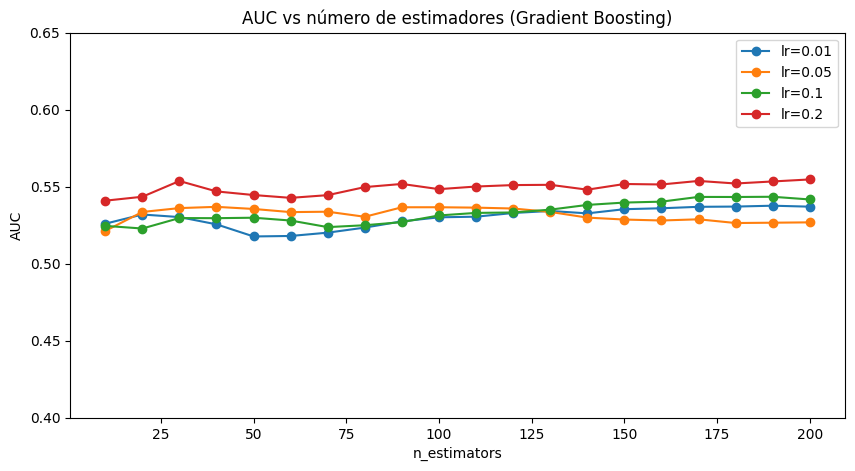


El mejor AUC es 0.5546 con n_estimators=200 y learning_rate=0.2


In [19]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 5 ####

kf = TimeSeriesSplit(n_splits=10)

n_estimators_gb = range(10, 210, 10)
learning_rates = [0.01, 0.05, 0.1, 0.2]

mejor_auc_gb = 0
mejor_n_est = 0
mejor_lr = 0
resultados_gb = []

for lr in learning_rates:
    auc_por_nestimators_gb = []
    for n in n_estimators_gb:
        auc_folds = []
        for train_idx, test_idx in kf.split(XTotal):
            X_trainCV, X_testCV = XTotal[train_idx], XTotal[test_idx]
            y_trainCV, y_testCV = yTotal[train_idx], yTotal[test_idx]

            clf = GradientBoostingClassifier(
                n_estimators=n,
                learning_rate=lr,
                max_depth=3,
                random_state=0
            ).fit(X_trainCV, y_trainCV)

            scores = clf.predict_proba(X_testCV)[:, 1]
            auc_folds.append(metrics.roc_auc_score(y_testCV, scores))

        media_auc = np.mean(auc_folds)
        auc_por_nestimators_gb.append(media_auc)

        if media_auc > mejor_auc_gb:
            mejor_auc_gb = media_auc
            mejor_n_est = n
            mejor_lr = lr

    resultados_gb.append((lr, auc_por_nestimators_gb))
    print(f"learning_rate={lr} completado — mejor AUC parcial: {max(auc_por_nestimators_gb):.4f}")

# Grafica
plt.figure(figsize=(10, 5))
plt.title("AUC vs número de estimadores (Gradient Boosting)")
for lr, aucs in resultados_gb:
    plt.plot(list(n_estimators_gb), aucs, marker='o', label=f'lr={lr}')
plt.xlabel("n_estimators")
plt.ylabel("AUC")
plt.ylim(0.4, 0.65)
plt.legend()
plt.show()

mejorauc_gboost = mejor_auc_gb
print(f"\nEl mejor AUC es {mejorauc_gboost:.4f} con n_estimators={mejor_n_est} y learning_rate={mejor_lr}")


### Análisis y Conclusión punto 5
Se implementó un modelo de Gradient Boosting utilizando los datos de Weekly, excluyendo la variable Today para evitar fuga de información. A diferencia de los modelos anteriores — donde los árboles se entrenan de forma independiente (bagging y Random Forest), Gradient Boosting entrena los árboles de manera secuencial, donde cada nuevo árbol se ajusta sobre los errores residuales del modelo acumulado anterior, lo que le otorga la capacidad de reducir tanto el sesgo como la varianza. Se utilizó una semilla igual a 0 para garantizar la reproducibilidad de los resultados.

En este caso, se calibraron dos hiperparámetros clave mediante un proceso iterativo combinado con validación cruzada. El primero es el número de estimadores (n_estimators), que se varió entre 10 y 200 en intervalos de 10, controlando la cantidad de árboles entrenados secuencialmente. El segundo es la tasa de aprendizaje (learning_rate), para la cual se evaluaron los valores 0.01, 0.05, 0.1 y 0.2; este parámetro escala la contribución de cada árbol al modelo final, regulando la velocidad de convergencia del algoritmo. Adicionalmente, se fijó una profundidad máxima de 3 para mantener los árboles base simples (weak learners) y reducir el riesgo de sobreajuste, dado que Gradient Boosting es más susceptible a overfitting que bagging. Para cada combinación de parámetros, se aplicó validación cruzada con 10 folds generados mediante TimeSeriesSplit, conservando la estructura temporal de los datos. Finalmente, para cada fold se calculó el AUC y se obtuvo el promedio entre folds, el cual fue utilizado para comparar las diferentes configuraciones y determinar el desempeño del modelo.

El modelo seleccionado mediante el proceso iterativo corresponde a 200 estimadores con una tasa de aprendizaje de 0.2, obteniendo un AUC de 0.5541. Al analizar el comportamiento por tasa de aprendizaje, se observa que tasas más altas (0.2) alcanzaron el mejor desempeño con un AUC de 0.5541, seguidas de la tasa 0.1 con 0.5437, mientras que las tasas más conservadoras (0.05 y 0.01) obtuvieron valores de 0.5374 y 0.5376 respectivamente. Esto sugiere que, para este dataset, tasas de aprendizaje más altas permiten al modelo captar más rápidamente las pocas señales predictivas existentes, sin que se evidencie un sobreajuste marcado dentro del rango evaluado.

En comparación con los modelos anteriores, Gradient Boosting (AUC = 0.5541) supera al modelo de árboles de decisión (AUC = 0.5355) por 0.0186 unidades y al modelo de bagging (AUC = 0.5495) por 0.0046 unidades. Esto es consistente con la teoría, ya que mientras bagging reduce únicamente la varianza promediando árboles independientes, Gradient Boosting también reduce el sesgo al corregir iterativamente los errores de los modelos previos. Sin embargo, las mejoras siguen siendo marginales debido a la naturaleza del dataset de Weekly, el cual contiene información de retornos del mercado financiero que en la práctica se comportan como un random walk, lo que limita inherentemente la capacidad de cualquier modelo para discriminar entre movimientos alcistas y bajistas utilizando únicamente información histórica. A pesar de estas limitaciones, Gradient Boosting se posiciona como el modelo con mejor desempeño entre los evaluados mediante validación cruzada temporal.

### 6. Selección del mejor modelo (10 puntos)
¿Cuál modelo de los estimados en este caso resulta mejor para la predicción de la variable de respuesta? Justifiquen su respuesta.

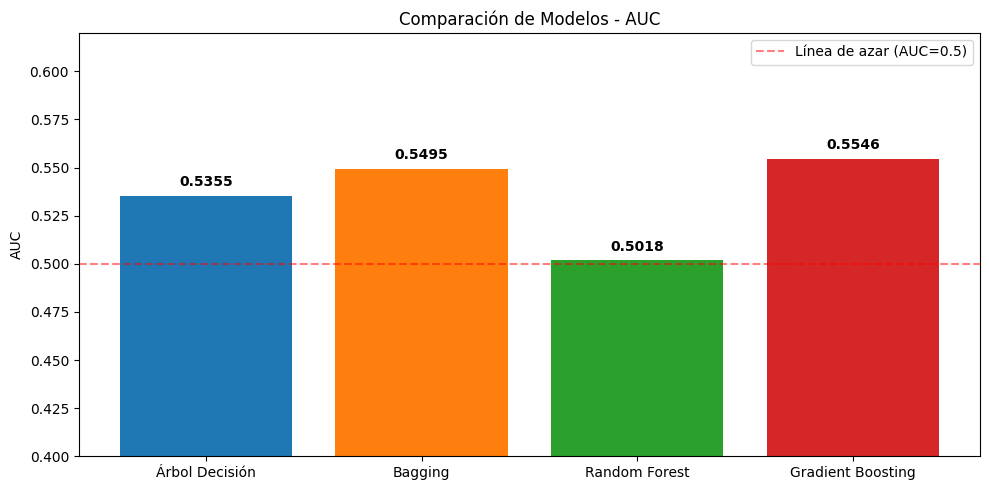


El mejor modelo es Gradient Boosting con un AUC de 0.5546

=== Métricas de evaluación en la muestra de Test (split temporal) ===


,Modelo,AUC (Test),Accuracy,Precision,Recall,F1-Score
Ranking,,,,,,
1,Gradient Boosting,0.500280,0.544444,0.546512,0.959184,0.696296
2,Árbol Decisión,0.484849,0.525000,0.538941,0.882653,0.669246
3,Random Forest,0.474630,0.533333,0.540462,0.954082,0.690037
4,Bagging,0.470197,0.522222,0.538217,0.862245,0.662745


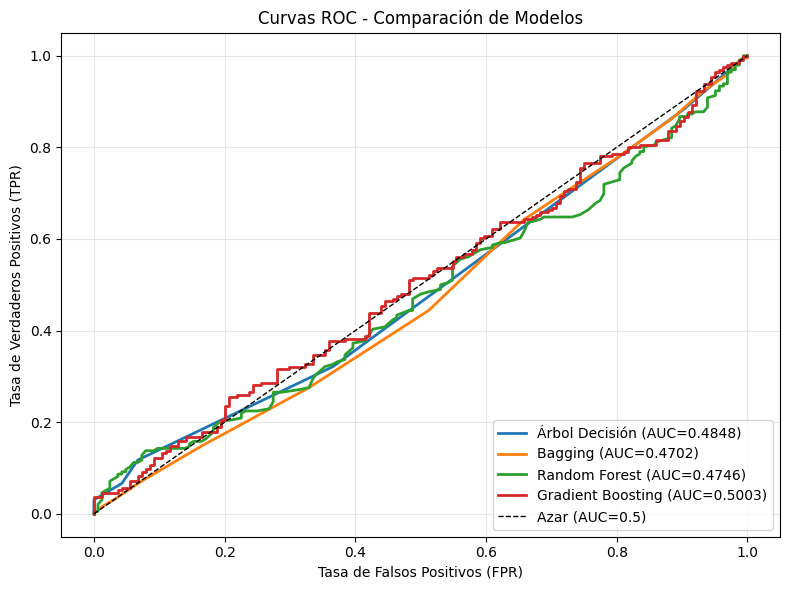

In [26]:
from sklearn.metrics import roc_curve, recall_score, f1_score, classification_report

# Gráfica comparativa de AUC
ejeX = ['Árbol Decisión', 'Bagging', 'Random Forest', 'Gradient Boosting']
ejeY = [mejorauc_Tree, mejorauc_bagg, auc_score_RF, mejorauc_gboost]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ejeX, ejeY, color=colors)
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{ejeY[i]:.4f}", ha='center', fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Línea de azar (AUC=0.5)')
ax.set_ylabel('AUC')
ax.set_title('Comparación de Modelos - AUC')
ax.set_ylim(0.40, 0.62)
ax.legend()
plt.tight_layout()
plt.show()

best_model_idx = np.argmax(ejeY)
print(f"\nEl mejor modelo es {ejeX[best_model_idx]} con un AUC de {ejeY[best_model_idx]:.4f}")

# Evaluación completa en muestra de Test (split temporal 67/33) ──
# Se entrenan los 4 modelos con sus mejores hiperparámetros sobre XTrain/yTrain
# y se evalúan sobre XTest/yTest para una comparación justa en la misma partición.

mejor_depth = max_depth[auc_por_depth.index(mejorauc_Tree)]
mejor_n_bag = n_estimators[auc_por_nestimators.index(mejorauc_bagg)]

mejores_modelos = {
    'Árbol Decisión': DecisionTreeClassifier(max_depth=mejor_depth, random_state=0),
    'Bagging': BaggingClassifier(n_estimators=mejor_n_bag, random_state=0),
    'Random Forest': RandomForestClassifier(n_estimators=500, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=mejor_n_est, learning_rate=mejor_lr, max_depth=3, random_state=0)
}

resultados_test = {}
for nombre, modelo in mejores_modelos.items():
    modelo.fit(XTrain, yTrain)
    probs = modelo.predict_proba(XTest)[:, 1]
    preds = modelo.predict(XTest)
    resultados_test[nombre] = {
        'AUC_Test': roc_auc_score(yTest, probs),
        'Accuracy': accuracy_score(yTest, preds),
        'Precision': precision_score(yTest, preds, pos_label='1'),
        'Recall': recall_score(yTest, preds, pos_label='1'),
        'F1': f1_score(yTest, preds, pos_label='1'),
        'probs': probs,
        'preds': preds
    }

# Tabla de métricas
df_metricas = pd.DataFrame({
    'Modelo': list(resultados_test.keys()),
    'AUC (Test)': [v['AUC_Test'] for v in resultados_test.values()],
    'Accuracy': [v['Accuracy'] for v in resultados_test.values()],
    'Precision': [v['Precision'] for v in resultados_test.values()],
    'Recall': [v['Recall'] for v in resultados_test.values()],
    'F1-Score': [v['F1'] for v in resultados_test.values()]
}).sort_values(by='AUC (Test)', ascending=False).reset_index(drop=True)
df_metricas.index = df_metricas.index + 1
df_metricas.index.name = 'Ranking'

print("\n=== Métricas de evaluación en la muestra de Test===")
display(df_metricas)

# Curvas ROC de todos los modelos
plt.figure(figsize=(8, 6))
nombres = list(resultados_test.keys())
for idx, nombre in enumerate(nombres):
    fpr, tpr, _ = roc_curve(yTest, resultados_test[nombre]['probs'], pos_label='1')
    auc_val = resultados_test[nombre]['AUC_Test']
    plt.plot(fpr, tpr, color=colors[idx], lw=2, label=f"{nombre} (AUC={auc_val:.4f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Azar (AUC=0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Análisis y Conclusión punto 6

**Metodología de comparación:** Para la selección del mejor modelo, primero se realizó una comparación directa de los AUC obtenidos en los puntos anteriores (árbol de decisión, bagging y gradient boosting; random forest). Adicionalmente, se entrenaron los cuatro modelos con sus mejores hiperparámetros sobre la misma partición temporal (67% entrenamiento, 33% test) para garantizar una comparación justa. Se evaluaron múltiples métricas — AUC, Accuracy, Precision, Recall y F1-Score — con el fin de obtener una visión integral del desempeño de cada modelo, dado que una sola métrica puede no reflejar completamente la calidad de las predicciones.

**Gráfica comparativa de AUC:** La gráfica de barras permite observar rápidamente el ranking de los modelos según el AUC reportado en cada punto. Todos los valores se encuentran entre 0.50 y 0.56, muy cercanos a la línea roja del azar (0.5), lo que confirma de entrada que el poder predictivo de todos los modelos es limitado. Gradient Boosting presenta el AUC más alto, seguido por Bagging, Árbol de Decisión y Random Forest.

**Tabla de métricas en test:** La tabla permite contrastar no solo el AUC sino también métricas de clasificación con umbral de 0.5: Accuracy (proporción general de aciertos), Precision (de las predicciones positivas, cuántas fueron correctas), Recall (de los verdaderos positivos, cuántos fueron detectados) y F1-Score (media armónica entre Precision y Recall). Estas métricas complementan el AUC porque permiten evaluar el comportamiento del modelo ante una decisión binaria concreta, no solo su capacidad de ordenar probabilidades. Dado el ligero desbalance de clases (~55.5% Up), un modelo que simplemente prediga siempre Up obtendría un Accuracy cercano a 0.55 sin capacidad real de discriminación, por lo que es fundamental analizar las métricas en conjunto.

**Curvas ROC:** Las curvas ROC superpuestas permiten visualizar la relación entre la tasa de verdaderos positivos (TPR) y la tasa de falsos positivos (FPR) en diferentes umbrales de clasificación. Las cuatro curvas se encuentran muy cercanas a la diagonal, confirmando visualmente que ninguno de los modelos logra una separación clara entre las clases Up y Down. Sin embargo, Gradient Boosting muestra un alejamiento ligeramente mayor de la diagonal en ciertos tramos, lo cual es consistente con su AUC superior.

**Justificación y limitaciones:** Aunque Gradient Boosting es el mejor modelo, es fundamental reconocer que todos obtienen un AUC cercano a 0.5, lo que implica una capacidad discriminativa muy limitada. Esto no se debe a una mala implementación, sino a las limitaciones inherentes del dataset: los retornos del mercado financiero tienden a comportarse como un proceso estocástico (random walk), donde la información histórica de retornos pasados tiene poco poder predictivo sobre movimientos futuros. Este resultado es consistente con la hipótesis de eficiencia del mercado (EMH) en su forma débil, la cual sostiene que los precios ya incorporan la información histórica disponible. Como se anticipó en el análisis exploratorio del punto 1, los boxplots y el correlograma ya mostraban que los predictores no ofrecen una separación clara entre las clases.

**Conclusión final:** Se selecciona **Gradient Boosting** como el mejor modelo por presentar el AUC más alto y por su fundamento teórico que le permite aprovechar mejor las señales débiles mediante aprendizaje secuencial. No obstante, dado su desempeño cercano al azar, no se recomienda su uso para toma de decisiones de inversión reales sin incorporar variables predictivas adicionales (indicadores técnicos, macroeconómicos, de sentimiento, etc.) que puedan aportar mayor poder discriminativo. La principal lección de este ejercicio es que la elección del algoritmo, si bien es importante, no puede compensar la falta de señal predictiva en los datos disponibles.